# Deriving Maxwell's Equations from the EM Lagrangian (SymPy, Checked Not Assumed)

Textbooks usually present the electromagnetic action
$S=\int L\,d^4x$, $L=-\frac{1}{4\mu_0}F_{\mu\nu}F^{\mu\nu}-J^\mu A_\mu$,
then simply STATE that varying it reproduces Maxwell's equations. This
notebook derives that claim step by step in SymPy: builds $F_{\mu\nu}$ from
a generic four-potential, checks it against the familiar $\mathbf E,\mathbf B$
component by component, decomposes the Lagrangian into the familiar
field-energy form, computes the canonical momentum by differentiating with
respect to 16 independent abstract derivative symbols (not the substituted
field), and confirms the resulting Euler-Lagrange equation IS Gauss's law
and the Ampere-Maxwell law -- with a separate check that the homogeneous
pair (Faraday's law, no monopoles) falls out of $F=dA$ for free. Engine:
`dgs/em_lagrangian_action.py`. Metric: $\eta=\mathrm{diag}(1,-1,-1,-1)$
(Griffiths' mostly-minus signature), coordinates $(x^0,x^1,x^2,x^3)=(ct,x,y,z)$.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import em_lagrangian_action as ema

sp.init_printing(use_latex='mathjax')
print('Setup complete.')


Setup complete.


## 1. Theory, Step by Step -- What Each Symbol Physically Means

**Step 1**: The four-potential $A^\mu=(V/c,\mathbf A)$ packages the scalar
and vector potentials into one Lorentz four-vector -- physically, $V$ and
$\mathbf A$ are not independent; a gauge transformation mixes them, and only
their combination $A^\mu$ transforms simply under a Lorentz boost.

**Step 2**: The field strength tensor
$F_{\mu\nu}=\partial_\mu A_\nu-\partial_\nu A_\mu$ is built purely from
derivatives of $A^\mu$ -- physically, it packages $\mathbf E$ and $\mathbf B$
into one antisymmetric object ($F_{0i}=E_i/c$, $F_{ij}=-\epsilon_{ijk}B_k$),
the field-theory analogue of how $A^\mu$ packages $V$ and $\mathbf A$.

**Step 3**: The Lagrangian density $L=-\frac{1}{4\mu_0}F_{\mu\nu}F^{\mu\nu}
-J^\mu A_\mu$ is a Lorentz scalar built from that tensor -- physically, its
free part must reduce to the familiar field energy density
$\frac{\varepsilon_0}{2}E^2-\frac{1}{2\mu_0}B^2$ when expanded in components,
since that's the quantity whose spacetime integral the true dynamics
extremizes.

**Step 4**: Varying $S=\int L\,d^4x$ with respect to $A_\nu$ gives the
Euler-Lagrange field equation
$\partial_\mu\!\left(\frac{\partial L}{\partial(\partial_\mu A_\nu)}\right)
-\frac{\partial L}{\partial A_\nu}=0$ -- physically, the canonical momentum
$\pi^{\mu\nu}=\partial L/\partial(\partial_\mu A_\nu)$ turns out to equal
$-F^{\mu\nu}/\mu_0$, so the field equation collapses to
$\partial_\mu F^{\mu\nu}=\mu_0 J^\nu$: Gauss's law and the Ampere-Maxwell law,
in one tensor equation.

**Step 5**: The remaining two Maxwell equations (Faraday's law, no magnetic
monopoles) need NO field equation at all -- they follow purely from
$F=dA$: since mixed partial derivatives of $A^\mu$ commute, the cyclic sum
$\partial_{[\lambda}F_{\mu\nu]}$ vanishes identically (the Bianchi identity),
for ANY potential, not just one that extremizes the action.


## 2. Field Tensor Built from a Generic Potential -- Checked Against E, B

`four_potential_symbols` creates $V(x),A_x(x),A_y(x),A_z(x)$ as fully
generic SymPy `Function`s of all four coordinates -- nothing about their
functional form is assumed. `field_strength_tensor` builds $F_{\mu\nu}$
from THOSE, and `verify_field_tensor_matches_E_B` checks every one of the
six independent components against the textbook $\mathbf E=-\nabla V-
\partial\mathbf A/\partial t$, $\mathbf B=\nabla\times\mathbf A$, defined
completely independently.


In [2]:
V, Ax, Ay, Az = ema.four_potential_symbols()
A_up, A_lo = ema.contravariant_and_covariant_potential(V, Ax, Ay, Az)
F_lo, F_up = ema.field_strength_tensor(A_lo)
E, B = ema.E_and_B_from_potentials(V, Ax, Ay, Az)

print('F_{mu nu} (covariant field strength tensor):')
sp.pprint(F_lo)

ok = ema.verify_field_tensor_matches_E_B(F_lo, E, B)
print(f'\nF_0i = E_i/c and F_ij = -eps_ijk B_k, verified component-by-component: {ok}')


F_{mu nu} (covariant field strength tensor):
⎡                                                                              ↪
⎢                                                                              ↪
⎢                                                       ∂                      ↪
⎢                        0                           - ───(Aₓ(x₀, x₁, x₂, x₃)) ↪
⎢                                                      ∂x₀                     ↪
⎢                                                                              ↪
⎢                           ∂                                                  ↪
⎢                          ───(V(x₀, x₁, x₂, x₃))                              ↪
⎢ ∂                        ∂x₁                                                 ↪
⎢───(Aₓ(x₀, x₁, x₂, x₃)) + ──────────────────────                            0 ↪
⎢∂x₀                                 c                                         ↪
⎢                                                               

In [3]:
# antisymmetry is a STRUCTURAL property of F = dA, true for ANY potential --
# checked directly rather than assumed
antisymmetric = all(sp.simplify(F_lo[mu, nu] + F_lo[nu, mu]) == 0
                     for mu in range(4) for nu in range(4))
diagonal_zero = all(sp.simplify(F_lo[mu, mu]) == 0 for mu in range(4))
print(f'F_lo is antisymmetric (F_mn = -F_nm): {antisymmetric}')
print(f'F_lo diagonal is identically zero:     {diagonal_zero}')


F_lo is antisymmetric (F_mn = -F_nm): True
F_lo diagonal is identically zero:     True


## 3. Lagrangian Decomposition -- The Action Integral's Integrand, Unpacked

$L_{\text{free}}=-\frac{1}{4\mu_0}F_{\mu\nu}F^{\mu\nu}$ is built directly
from the tensor above. `verify_lagrangian_reduces_to_field_energy` expands
it algebraically and checks it against $\frac{\varepsilon_0}{2}E^2-
\frac{1}{2\mu_0}B^2$ using $\mu_0=1/(\varepsilon_0 c^2)$ -- this is the step
that recovers the familiar "electric minus magnetic energy density" form
from the abstract tensor contraction.


In [4]:
L_free = ema.free_lagrangian_density(F_lo, F_up)
ok = ema.verify_lagrangian_reduces_to_field_energy(L_free, E, B)
print(f'L_free = -1/(4 mu0) F_munu F^munu  decomposes to  (eps0/2)E^2 - B^2/(2 mu0): {ok}')

# a Lagrangian off by a stray factor must be CAUGHT, not silently pass --
# confirms the verifier actually discriminates
try:
    ema.verify_lagrangian_reduces_to_field_energy(2*L_free, E, B)
    print('BUG: a Lagrangian off by 2x was not caught')
except AssertionError as e:
    print(f'A Lagrangian off by 2x correctly raises: {str(e)[:70]}...')


L_free = -1/(4 mu0) F_munu F^munu  decomposes to  (eps0/2)E^2 - B^2/(2 mu0): True
A Lagrangian off by 2x correctly raises: L_free did not reduce to (eps0/2)E^2 - B^2/(2 mu0): leftover epsilon_0...


## 4. Canonical Momentum and the Euler-Lagrange Field Equation

`canonical_momentum_density` computes
$\pi^{\mu\nu}=\partial L_{\text{free}}/\partial(\partial_\mu A_\nu)$ by
treating each of the 16 partial derivatives $\partial_\mu A_\nu$ as an
INDEPENDENT variable first (the field-theory analogue of $\partial
L/\partial\dot q$ in point mechanics), only substituting the concrete field
back in afterward -- doing it the other way around (differentiating the
already-substituted $L_{\text{free}}$ with respect to "$A_\nu$") would be
meaningless, since $L_{\text{free}}$ doesn't depend on $A_\nu$ itself, only
its derivatives.


In [5]:
pi_generic, F_up_generic = ema.canonical_momentum_density()
ok = ema.verify_canonical_momentum_matches_F(pi_generic, F_up_generic)
print(f'pi^(mu nu) = dL_free/d(d_mu A_nu)  equals  -F^(mu nu)/mu0: {ok}')


pi^(mu nu) = dL_free/d(d_mu A_nu)  equals  -F^(mu nu)/mu0: True


In [6]:
rho, Jx, Jy, Jz = ema.four_current_symbols()
J_up = [ema.C*rho, Jx, Jy, Jz]

div_F, residual = ema.euler_lagrange_maxwell_equation(F_up, J_up)
ok = ema.verify_gauss_and_ampere_maxwell(div_F, E, B)
print(f'd_mu F^(mu nu) = mu0 J^nu  reduces to Gauss (nu=0) + Ampere-Maxwell (nu=1,2,3): {ok}')

print()
for nu, name in enumerate(('nu=0 (Gauss)', 'nu=1 (Ampere-Maxwell x)',
                            'nu=2 (Ampere-Maxwell y)', 'nu=3 (Ampere-Maxwell z)')):
    print(f'{name}: d_mu F^(mu {nu}) =')
    sp.pprint(div_F[nu])
    print()


d_mu F^(mu nu) = mu0 J^nu  reduces to Gauss (nu=0) + Ampere-Maxwell (nu=1,2,3): True



nu=0 (Gauss): d_mu F^(mu 0) =
  ⎛     2                             2                              2         ↪
  ⎜    ∂                             ∂                              ∂          ↪
c⋅⎜- ───────(Aₓ(x₀, x₁, x₂, x₃)) - ───────(A_y(x₀, x₁, x₂, x₃)) - ───────(A_z( ↪
  ⎝  ∂x₁ ∂x₀                       ∂x₂ ∂x₀                        ∂x₃ ∂x₀      ↪
                                                                               ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                                               ↪

↪                 ⎞     2                         2                         2  ↪
↪                 ⎟    ∂                         ∂                         ∂   ↪
↪ x₀, x₁, x₂, x₃))⎟ - ────(V(x₀, x₁, x₂, x₃)) - ────(V(x₀, x₁, x₂, x₃)) - ──── ↪
↪                 ⎠      2                         2                         2 ↪
↪                     ∂x₁                       ∂x₂                       ∂x

## 5. Bianchi Identity -- Faraday's Law and No Monopoles, for Free

$\partial_\lambda F_{\mu\nu}+\partial_\mu F_{\nu\lambda}+\partial_\nu
F_{\lambda\mu}=0$ must hold IDENTICALLY whenever $F=dA$ (mixed partials
commute) -- no field equation, no equations of motion, no dynamics
required. To confirm the check is actually discriminating (not just always
returning True), it's also run on a GENERIC antisymmetric tensor with no
underlying potential, which must FAIL.


In [7]:
ok = ema.verify_bianchi_identity(F_lo)
print(f'Bianchi identity holds identically for F = dA: {ok}')

# a generic antisymmetric tensor with no underlying potential should NOT
# satisfy Bianchi -- if it did, the check would be vacuous
generic_antisym = sp.zeros(4, 4)
for mu in range(4):
    for nu in range(mu+1, 4):
        g = sp.Function(f'G_{mu}{nu}')(*ema.COORDS)
        generic_antisym[mu, nu] = g
        generic_antisym[nu, mu] = -g

try:
    ema.verify_bianchi_identity(generic_antisym)
    print('BUG: an arbitrary antisymmetric tensor should NOT satisfy Bianchi')
except AssertionError as e:
    print(f'An arbitrary antisymmetric tensor (not F=dA) correctly FAILS Bianchi: {str(e)[:70]}...')


Bianchi identity holds identically for F = dA: True
An arbitrary antisymmetric tensor (not F=dA) correctly FAILS Bianchi: Bianchi identity failed for (lambda,mu,nu)=(0,1,2): Derivative(G_01(x0...


## 6. Full Orchestration: Every Claim, Verified

`derive_maxwell_from_lagrangian` runs the entire chain above from scratch
and returns every intermediate object plus every verification's outcome --
the single entry point a reader (or a resume bullet) can point to.


In [8]:
result = ema.derive_maxwell_from_lagrangian()
for key in ('field_tensor_matches_E_B', 'lagrangian_reduces_to_field_energy',
            'canonical_momentum_matches_F', 'maxwell_inhomogeneous_verified',
            'bianchi_identity_verified'):
    print(f'{key:38s} {result[key]}')


field_tensor_matches_E_B               True


lagrangian_reduces_to_field_energy     True
canonical_momentum_matches_F           True
maxwell_inhomogeneous_verified         True
bianchi_identity_verified              True


## 7. Concrete Example: a Vacuum Plane Wave Solves the Sourceless Field Equation

Everything above used a fully GENERIC potential. As a concrete check, plug
in an actual solution: $A_y=A_0\sin\!\big(k(x^1-x^0)\big)$, $A_x=A_z=V=0$ --
a function of the single NULL combination $x^1-x^0$. Because $x^0=ct$
already absorbs the factor of $c$, any function of $x^1-x^0$ alone solves
the free wave equation identically, for ANY $k$ -- no separate dispersion
relation needs to be imposed or substituted in afterward. (An earlier draft
of this notebook wrote the phase as $kx^1-\omega x^0$ with $\omega=ck$ and
found a leftover $(c^2-1)$ residual -- that was double-counting the speed of
light, since $x^0$ already carries it. The null-combination form avoids the
mistake entirely.)


In [9]:
A0, k = sp.symbols('A_0 k', positive=True)
x0, x1 = ema.X0, ema.X1

V_wave, Ax_wave, Az_wave = sp.Integer(0), sp.Integer(0), sp.Integer(0)
Ay_wave = A0*sp.sin(k*(x1 - x0))

A_up_wave, A_lo_wave = ema.contravariant_and_covariant_potential(V_wave, Ax_wave, Ay_wave, Az_wave)
F_lo_wave, F_up_wave = ema.field_strength_tensor(A_lo_wave)
E_wave, B_wave = ema.E_and_B_from_potentials(V_wave, Ax_wave, Ay_wave, Az_wave)

print('E_y =', E_wave[1])
print('B_z =', B_wave[2])
print('E_y / B_z =', sp.simplify(E_wave[1]/B_wave[2]), ' (matches the standard vacuum-wave relation E = cB)')
print('(all other E, B components are exactly 0 for this wave)')

div_F_wave, _ = ema.euler_lagrange_maxwell_equation(F_up_wave, [0, 0, 0, 0])
print('\nd_mu F^(mu nu) for nu=0..3, with NO substitution -- true for any k, A0, c:')
print(div_F_wave, ' (all zero => the wave solves the SOURCE-FREE field equation exactly)')


E_y = A_0*c*k*cos(k*(-x0 + x1))
B_z = A_0*k*cos(k*(-x0 + x1))
E_y / B_z = c  (matches the standard vacuum-wave relation E = cB)
(all other E, B components are exactly 0 for this wave)

d_mu F^(mu nu) for nu=0..3, with NO substitution -- true for any k, A0, c:
[0, 0, 0, 0]  (all zero => the wave solves the SOURCE-FREE field equation exactly)


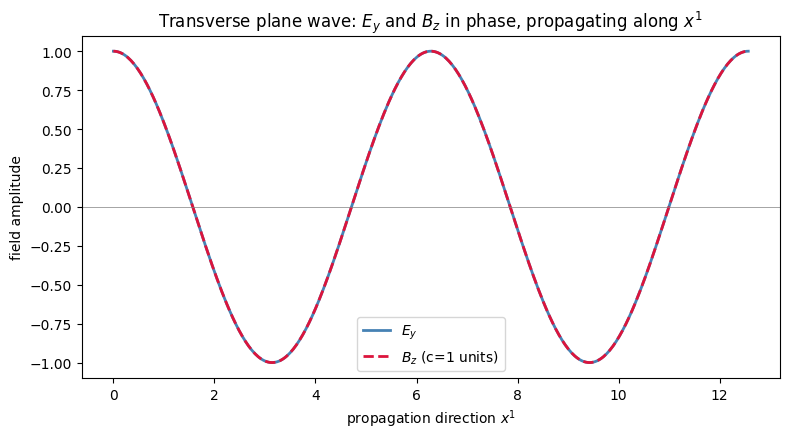

In [10]:
# visualize the transverse E-B wave at a fixed time snapshot (c=1 units for the plot)
x1_vals = np.linspace(0, 4*np.pi, 400)
Ey_func = sp.lambdify((x1, x0, A0, k), E_wave[1].subs(ema.C, 1), 'numpy')
Bz_func = sp.lambdify((x1, x0, A0, k), B_wave[2].subs(ema.C, 1), 'numpy')

Ey_vals = Ey_func(x1_vals, 0.0, 1.0, 1.0)
Bz_vals = Bz_func(x1_vals, 0.0, 1.0, 1.0)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x1_vals, Ey_vals, color='steelblue', lw=2, label='$E_y$')
ax.plot(x1_vals, Bz_vals, color='crimson', lw=2, ls='--', label='$B_z$ (c=1 units)')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('propagation direction $x^1$'); ax.set_ylabel('field amplitude')
ax.set_title('Transverse plane wave: $E_y$ and $B_z$ in phase, propagating along $x^1$')
ax.legend()
plt.tight_layout()
plt.savefig('em_lagrangian_plane_wave.png', dpi=100, bbox_inches='tight')
plt.show()


## 8. Engineering Interpretation

- Section 4's canonical-momentum step is the crux: it's exactly the same
  "differentiate with respect to an independent derivative symbol, THEN
  substitute the concrete field" procedure `dgs/torch_autograd_dag.py`
  automates with `torch.autograd.grad` -- here done by hand with abstract
  SymPy symbols, there done by walking a real backward graph. Same
  underlying idea (canonical momentum / adjoint sensitivity), two different
  tools.
- Section 5's Bianchi-identity negative check (an arbitrary antisymmetric
  tensor correctly FAILS) is the same discipline as
  `dgs/financial_math_torch.py`'s validation tests: a checker that always
  returns True on real inputs is unconvincing until it's shown to return
  False on a deliberately broken one.
- Section 7's plane wave is the standard "first nontrivial solution" check
  in field theory: a fully general derivation is trustworthy only once it
  reproduces a solution whose properties (transverse, $E\perp B$, $\omega=ck$)
  are independently known.


## 9. Research Discussion

- The Bianchi identity holding for ANY $F=dA$ (section 5) is the field-theory
  reason magnetic monopoles are usually introduced by hand (a nonzero
  magnetic charge density) rather than derived -- could this module's
  `field_strength_tensor` be extended to build $F$ from a potential with a
  Dirac string singularity, and show the identity fails exactly at the
  monopole location?
- Section 3's Lagrangian decomposition used $\mu_0=1/(\varepsilon_0 c^2)$
  (vacuum). Could `free_lagrangian_density` be generalized to a linear
  dielectric ($\varepsilon,\mu\neq\varepsilon_0,\mu_0$) and re-checked
  against `dgs/connective_tissue_electrodynamics.py`'s causal
  $\varepsilon(\omega)$, connecting this Lagrangian derivation to that
  module's Kramers-Kronig work?
- Section 7 checked ONE plane-wave solution. Could
  `euler_lagrange_maxwell_equation` be used to symbolically verify a
  spherical multipole radiation solution instead, connecting this notebook
  to `dgs`'s existing radiation/antenna modules?


## 10. Possible Experiments

1. Repeat section 7 with a source term (nonzero $J^\mu$) matching a known
   radiating configuration (e.g. an oscillating dipole current) and confirm
   `euler_lagrange_maxwell_equation`'s residual matches the known retarded
   potential solution rather than vanishing.
2. Extend `field_strength_tensor` to accept a NON-diagonal metric (e.g. a
   weak gravitational-wave background) and see whether
   `verify_lagrangian_reduces_to_field_energy`'s target expression needs
   modification, or whether the tensor formalism handles it unchanged.
3. Symbolically verify energy-momentum conservation
   ($\partial_\mu T^{\mu\nu}=0$) from this same Lagrangian via Noether's
   theorem, the natural next claim after "the field equations are correct."


## 11. Future Improvements

- `verify_bianchi_identity` currently iterates all $\binom{4}{3}=4$ index
  triples with plain Python loops; for a reader who wants the general
  $n$-dimensional Bianchi identity (differential-form language,
  $dF=0$), a `sympy.diffgeom`-based version would generalize beyond 4D
  spacetime.
- If this derivation needs to feed into a numerical solver later (e.g.
  FDTD, matching `dgs`'s other EM modules), `euler_lagrange_maxwell_equation`
  could be lambdified into a callable residual for a PDE solver instead of
  staying purely symbolic.
